In [244]:
import numpy as np
import matplotlib.pyplot as plt 

from IPython import display
%config InlineBackend.figure_format = 'svg'

In [245]:
x = np.linspace(-2,2,2001)

def fx(x):
  return 3*x**2 - 3*x + 4

def deriv(x):
  return 6*x - 3

In [246]:
# localmin = np.random.choice(x,1)
# initval = localmin[:] 
localmin = np.array([-0.8])  
initval = localmin[:]

learning_rate = .01
training_epochs = 50

modelparamsGrad = np.zeros((training_epochs,3))
for i in range(training_epochs):

  grad = deriv(localmin)

  lr = learning_rate*np.abs(grad)

  localmin = localmin - lr*grad

  modelparamsGrad[i,0] = localmin[0]
  modelparamsGrad[i,1] = grad[0]
  modelparamsGrad[i,2] = lr[0]

In [247]:
learning_rate = .1
# localmin = initval
localmin = np.array([0.2])  
initval = localmin[:]

modelparamsTime = np.zeros((training_epochs,3))
for i in range(training_epochs):
  grad = deriv(localmin)
  lr = learning_rate*(1-(i+1)/training_epochs)
  localmin = localmin - lr*grad
  modelparamsTime[i,0] = localmin[0]
  modelparamsTime[i,1] = grad[0]
  modelparamsTime[i,2] = lr

average_lr=np.mean(modelparamsTime[:,2])

# localmin = np.random.choice(x,1)
# initval = localmin[:]
localmin = np.array([0.7])  
initval = localmin[:]

learning_rate = .01
training_epochs = 50

modelparamsFixed = np.zeros((training_epochs,3))
for i in range(training_epochs):

  grad = deriv(localmin)

  lr = average_lr

  localmin = localmin - lr*grad

  modelparamsFixed[i,0] = localmin[0]
  modelparamsFixed[i,1] = grad[0]
  modelparamsFixed[i,2] = lr

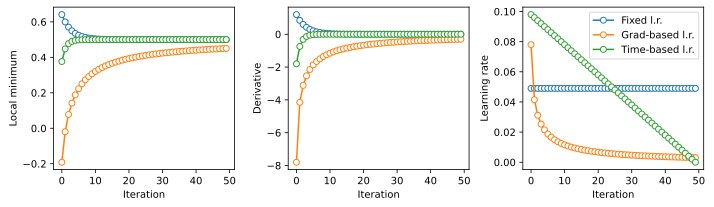

In [248]:

fig,ax = plt.subplots(1,3,figsize=(10,3))
for i in range(3):
  ax[i].plot(modelparamsFixed[:,i],'o-',markerfacecolor='w')
  ax[i].plot(modelparamsGrad[:,i],'o-',markerfacecolor='w')
  ax[i].plot(modelparamsTime[:,i],'o-',markerfacecolor='w')
  ax[i].set_xlabel('Iteration')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')
ax[2].set_ylabel('Learning rate')
ax[2].legend(['Fixed l.r.','Grad-based l.r.','Time-based l.r.'])

plt.tight_layout()
plt.show()
     
